# Vietnamese Hate Speech Detection
## PhoBERT (base & pretrain) — Stratified K-Fold Fine-tune & Evaluation

## 0. Install & Imports

In [ ]:
!pip install -q transformers datasets accelerate sentencepiece openpyxl scikit-learn seaborn
!pip install -q underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 54.3 MB/s eta 0:00:00


In [ ]:
# Xóa checkpoint, output train
!rm -rf /content/ckpt_*
!rm -rf /content/runs
!rm -rf /content/wandb

# Xóa cache Hugging Face
!rm -rf ~/.cache/huggingface

# Xóa cache pip
!rm -rf ~/.cache/pip

# Xóa cache torch
!rm -rf ~/.cache/torch

# Xóa cache CUDA
!rm -rf ~/.nv

# Xóa file tạm trong /tmp
!rm -rf /tmp/*

# Xóa mọi thứ trong /content trừ Google Drive
!find /content -mindepth 1 -maxdepth 1 ! -name drive -exec rm -rf {} +

In [ ]:
import os, warnings, re, sys
warnings.filterwarnings('ignore')
sys.modules.pop('torchvision', None)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, recall_score
)
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed
)
import torch.nn as nn

set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## 1. Mount Google Drive & Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
EXCEL_PATH = '/content/drive/MyDrive/Data_final (1).xlsx'

df_raw = pd.read_excel(EXCEL_PATH, sheet_name='tiktok')
df_raw = df_raw[['text', 'label']].dropna()
df_raw['label'] = df_raw['label'].astype(int)
df_raw = df_raw[df_raw['text'].apply(lambda x: isinstance(x, str))].reset_index(drop=True)

print('Shape:', df_raw.shape)
print('Label distribution:')
print(df_raw['label'].value_counts().sort_index())

Shape: (59671, 2)
Label distribution:
label
0    58675
1      803
2      193
Name: count, dtype: int64


## 2. Chuẩn hóa teencode (toàn bộ dataset)

In [ ]:
# # ── Bỏ comment block này nếu không muốn chuẩn hóa ──
# teencode_df = pd.read_excel('/content/drive/MyDrive/Teencode.xlsx')
# teencode_dict = {
#     str(k).lower(): str(v)
#     for k, v in zip(teencode_df['teencode'], teencode_df['text'])
# }
# tc_pattern = re.compile(
#     r'\b(' + '|'.join(map(re.escape, teencode_dict.keys())) + r')\b',
#     flags=re.IGNORECASE
# )

# def normalize_teencode(sentence):
#     if not isinstance(sentence, str):
#         return sentence
#     return tc_pattern.sub(lambda m: teencode_dict.get(m.group(0).lower(), m.group(0)), sentence)

# original_texts = df_raw['text'].copy()
# df_raw['text'] = df_raw['text'].apply(normalize_teencode)

# changed_mask = original_texts != df_raw['text']
# print(f'Số comment được chuẩn hóa: {changed_mask.sum()}')
# for idx in changed_mask.to_numpy().nonzero()[0][:10]:
#     print('=' * 80)
#     print('TRƯỚC :', original_texts.iloc[idx])
#     print('SAU   :', df_raw['text'].iloc[idx])
# # ── Kết thúc block chuẩn hóa ──

## 3. Class Imbalance Analysis

Dataset counts per class: {0: 58675, 1: 803, 2: 193}


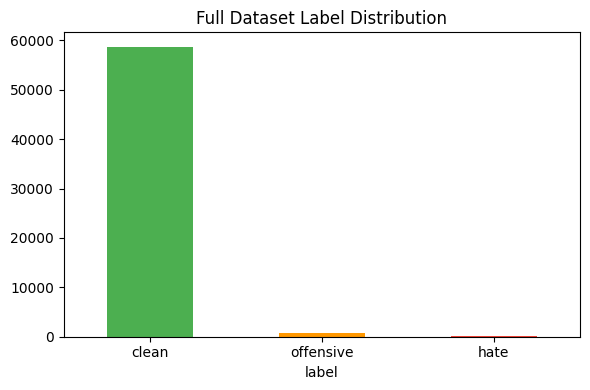

In [ ]:
label_names = {0: 'clean', 1: 'offensive', 2: 'hate'}
counts = df_raw['label'].value_counts().sort_index()
print('Dataset counts per class:', counts.to_dict())

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax, color=['#4CAF50', '#FF9800', '#F44336'])
ax.set_title('Full Dataset Label Distribution')
ax.set_xticklabels([label_names[i] for i in sorted(counts.index)], rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100)
plt.show()

## 4. Class Weights — Inverse Frequency

In [ ]:
N          = len(df_raw)
n_classes  = 3
counts_arr = np.array([counts[i] for i in range(n_classes)], dtype=float)

w_inv = N / (n_classes * counts_arr)
w_inv = w_inv / w_inv.sum() * n_classes

print('inv_freq weights (clean, offensive, hate):', np.round(w_inv, 3))

inv_freq weights (clean, offensive, hate): [0.008 0.58  2.412]


## 5. Helpers

In [ ]:
def evaluate_predictions(y_true, y_pred, dataset_name='', model_name=''):
    acc     = accuracy_score(y_true, y_pred)
    f1mac   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    recalls = recall_score(y_true, y_pred, average=None, zero_division=0)
    report  = classification_report(y_true, y_pred,
                                    target_names=['clean', 'offensive', 'hate'],
                                    zero_division=0)
    result = {
        'model'        : model_name,
        'dataset'      : dataset_name,
        'acc'          : round(acc, 4),
        'f1_macro'     : round(f1mac, 4),
        'recall_clean' : round(recalls[0], 4) if len(recalls) > 0 else None,
        'recall_off'   : round(recalls[1], 4) if len(recalls) > 1 else None,
        'recall_hate'  : round(recalls[2], 4) if len(recalls) > 2 else None,
    }
    print(f'\n[{model_name}] on [{dataset_name}]')
    print(f'  Acc={acc:.4f}  F1_macro={f1mac:.4f}  '
          f'Recall(off)={recalls[1]:.4f}  Recall(hate)={recalls[2]:.4f}')
    print(report)
    return result


class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=self.class_weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro', zero_division=0),
    }


def make_hf_dataset(df, tokenizer, max_len=256):
    ds = Dataset.from_pandas(df[['text', 'label']].reset_index(drop=True))
    ds = ds.map(
        lambda b: tokenizer(b['text'], truncation=True, max_length=max_len),
        batched=True, remove_columns=['text']
    )
    ds = ds.rename_column('label', 'labels')
    ds.set_format('torch')
    return ds

In [ ]:
import sys
sys.modules.pop("torchvision", None)

## 6. Stratified K-Fold Fine-tune — PhoBERT Base & Pretrain

In [ ]:
MODELS = {
    'phobert_base': 'vinai/phobert-base-v2',
    'phobert_pretrain': 'KalvinPhan/PhoBert-Pretrain',
}

K_FOLDS     = 5
skf         = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
all_results = []

for model_key, model_path in MODELS.items():
    print(f'\n{"="*80}')
    print(f'MODEL: {model_key}  ({model_path})')
    print(f'{"="*80}')

    tokenizer        = AutoTokenizer.from_pretrained(model_path)
    fold_preds_all   = np.empty(len(df_raw), dtype=int)
    fold_metrics     = []

    for fold, (train_idx, val_idx) in enumerate(
            skf.split(df_raw['text'], df_raw['label'])):
        print(f'\n--- Fold {fold+1}/{K_FOLDS} ---')

        train_fold = df_raw.iloc[train_idx].reset_index(drop=True)
        val_fold   = df_raw.iloc[val_idx].reset_index(drop=True)

        fold_counts = np.array(
            [train_fold['label'].value_counts().get(i, 1) for i in range(n_classes)],
            dtype=float
        )
        fold_w = len(train_fold) / (n_classes * fold_counts)
        fold_w = fold_w / fold_w.sum() * n_classes

        train_ds = make_hf_dataset(train_fold, tokenizer)
        val_ds   = make_hf_dataset(val_fold,   tokenizer)

        model = AutoModelForSequenceClassification.from_pretrained(
            model_path, num_labels=3, ignore_mismatched_sizes=True
        ).to(DEVICE)

        args = TrainingArguments(
            output_dir=f'./ckpt_{model_key}_fold{fold+1}',
            num_train_epochs=2,
            per_device_train_batch_size=32,
            per_device_eval_batch_size=32,
            learning_rate=2e-5,
            warmup_ratio=0.1,
            weight_decay=0.01,
            eval_strategy='epoch',
            save_strategy='epoch',
            load_best_model_at_end=True,
            metric_for_best_model='f1_macro',
            greater_is_better=True,
            logging_steps=50,
            fp16=True,
            report_to='none',
            seed=42,
        )

        trainer = WeightedTrainer(
            class_weights=fold_w,
            model=model,
            args=args,
            train_dataset=train_ds,
            eval_dataset=val_ds,
            processing_class=tokenizer,
            data_collator=DataCollatorWithPadding(tokenizer),
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
        )
        trainer.train()

        preds_out = trainer.predict(val_ds)
        fold_pred = np.argmax(preds_out.predictions, axis=-1)
        fold_preds_all[val_idx] = fold_pred

        f1   = f1_score(val_fold['label'], fold_pred, average='macro', zero_division=0)
        acc  = accuracy_score(val_fold['label'], fold_pred)
        recs = recall_score(val_fold['label'], fold_pred, average=None, zero_division=0)
        fold_metrics.append({
            'fold': fold+1, 'acc': acc, 'f1_macro': f1,
            'recall_off': recs[1], 'recall_hate': recs[2]
        })
        print(f'  Fold {fold+1}: Acc={acc:.4f}  F1={f1:.4f}  '
              f'Recall(off)={recs[1]:.4f}  Recall(hate)={recs[2]:.4f}')

        del model, trainer
        torch.cuda.empty_cache()

    fold_df  = pd.DataFrame(fold_metrics)
    mean_row = fold_df.drop(columns='fold').mean()
    std_row  = fold_df.drop(columns='fold').std()

    print(f'\n[{model_key}] Per-fold results:')
    print(fold_df.to_string(index=False))
    print(f'\n[{model_key}] Mean ± Std across {K_FOLDS} folds:')
    for col in mean_row.index:
        print(f'  {col}: {mean_row[col]:.4f} ± {std_row[col]:.4f}')

    res = evaluate_predictions(
        df_raw['label'].tolist(), fold_preds_all,
        dataset_name='oof_full', model_name=model_key
    )
    res['fold_f1_mean'] = round(float(mean_row['f1_macro']), 4)
    res['fold_f1_std']  = round(float(std_row['f1_macro']),  4)
    all_results.append(res)


MODEL: phobert_base  (vinai/phobert-base-v2)


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.680044,0.515076,0.982319,0.518476
2,0.558205,0.622738,0.988688,0.673497


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.laye

  Fold 5: Acc=0.9887  F1=0.6735  Recall(off)=0.6770  Recall(hate)=0.2632

[phobert_pretrain] Per-fold results:
 fold      acc  f1_macro  recall_off  recall_hate
    1 0.986008  0.617539    0.664596     0.205128
    2 0.987096  0.678546    0.681250     0.333333
    3 0.989442  0.728097    0.743750     0.435897
    4 0.989107  0.644460    0.714286     0.157895
    5 0.988688  0.673497    0.677019     0.263158

[phobert_pretrain] Mean ± Std across 5 folds:
  acc: 0.9881 ± 0.0015
  f1_macro: 0.6684 ± 0.0414
  recall_off: 0.6962 ± 0.0323
  recall_hate: 0.2791 ± 0.1095

[phobert_pretrain] on [oof_full]
  Acc=0.9881  F1_macro=0.6703  Recall(off)=0.6961  Recall(hate)=0.2798
              precision    recall  f1-score   support

       clean       0.99      0.99      0.99     58675
   offensive       0.64      0.70      0.67       803
        hate       0.47      0.28      0.35       193

    accuracy                           0.99     59671
   macro avg       0.70      0.66      0.67     59671

## 7. Summary Table

In [ ]:
results_df   = pd.DataFrame(all_results)
display_cols = ['model', 'dataset', 'acc', 'f1_macro', 'fold_f1_mean', 'fold_f1_std',
                'recall_clean', 'recall_off', 'recall_hate']
summary = results_df[display_cols].copy()
summary.columns = ['Model', 'Dataset', 'OOF Acc', 'OOF F1 Macro',
                   'Fold F1 Mean', 'Fold F1 Std',
                   'Recall(clean)', 'Recall(off)', 'Recall(hate)']

print('=' * 100)
print('FINAL RESULTS SUMMARY')
print('=' * 100)
print(summary.to_string(index=False))
summary.to_csv('results_summary.csv', index=False)
print('\nSaved to results_summary.csv')

FINAL RESULTS SUMMARY
           Model  Dataset  OOF Acc  OOF F1 Macro  Fold F1 Mean  Fold F1 Std  Recall(clean)  Recall(off)  Recall(hate)
    phobert_base oof_full   0.9847        0.5002        0.4996       0.0174         0.9946       0.5031        0.0000
phobert_pretrain oof_full   0.9881        0.6703        0.6684       0.0414         0.9944       0.6961        0.2798

Saved to results_summary.csv


## 8. Visualizations

In [ ]:
metrics_to_plot = ['OOF Acc', 'OOF F1 Macro', 'Recall(off)', 'Recall(hate)']
fig, ax = plt.subplots(figsize=(8, 4))
sub = summary.set_index('Model')[metrics_to_plot]
sns.heatmap(sub.astype(float), annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Model Comparison — OOF Metrics', fontsize=13)
plt.tight_layout()
plt.savefig('results_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (model_key, _) in zip(axes, MODELS.items()):
    res = results_df[results_df['model'] == model_key].iloc[0]
    vals = [res['acc'], res['f1_macro'], res['recall_off'], res['recall_hate']]
    ax.bar(['OOF Acc', 'OOF F1', 'Recall(off)', 'Recall(hate)'], vals,
           color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'])
    ax.set_ylim(0, 1)
    ax.set_title(model_key)
plt.tight_layout()
plt.savefig('model_bar_comparison.png', dpi=120)
plt.show()

## 9. Save Models to Drive (Optional)

In [ ]:
SAVE_TO_DRIVE = False

if SAVE_TO_DRIVE:
    tokenizer.save_pretrained('/content/drive/MyDrive/phobert_vihsd_finetuned')
    print('Tokenizer saved.')